# Day3.5 — Can Few-Shot Adaptation Rescue B1?

## Goal
Test whether the B1 anomaly discovered in Day2+ can be rescued by the same few-shot adaptation pipeline used in Day3.

**Scientific question:** Can few-shot adaptation remove B1 high-concentration response compression, or does B1 remain target-intrinsic after adaptation?

**Source boards:** B2, B3, B4, B5  
**Target board:** B1  
**Few-shot levels:** 0, 1, 2, 5, 10 samples per concentration  
**Methods:** mean/std alignment, linear recalibration, residual ridge, RF retraining, RF weighted retraining

## Section 0 — Setup and Debug Review Inputs

### Goal
Create a robust, reproducible notebook that can run from the project root or from the `notebooks/` directory.

### Method
- Resolve project paths.
- Load processed features if available.
- Otherwise build features from raw `.txt` files.
- Use fixed `random_state`.
- Save all figures to `figures/` and tables to `results/`.

In [1]:
from pathlib import Path
import re
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.base import clone

RANDOM_STATE = 42
# Memory-safe defaults. Increase only after the notebook runs successfully.
N_REPEATS = 5
RF_N_ESTIMATORS = 80
RF_N_ESTIMATORS_RETRAIN = 60
RF_N_JOBS = 1
np.random.seed(RANDOM_STATE)

# Resolve project root robustly.
cwd = Path.cwd().resolve()
if cwd.name == "notebooks":
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

DATA_RAW = PROJECT_ROOT / "data" / "raw"
FIGURES_DIR = PROJECT_ROOT / "figures"
RESULTS_DIR = PROJECT_ROOT / "results"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_RAW exists:", DATA_RAW.exists())
print("FIGURES_DIR:", FIGURES_DIR)
print("RESULTS_DIR:", RESULTS_DIR)

PROJECT_ROOT: C:\Users\hg\PycharmProjects\mox_calibration_transfer
DATA_RAW exists: True
FIGURES_DIR: C:\Users\hg\PycharmProjects\mox_calibration_transfer\figures
RESULTS_DIR: C:\Users\hg\PycharmProjects\mox_calibration_transfer\results


## Section 0.1 — Load or Build Feature Table

### Goal
Use the same feature representation as previous notebooks whenever possible.

### Method
The loader searches common result filenames first. If no processed feature table is found, it builds compact statistical features from raw time-series files.

Expected metadata columns:
- `board`
- `gas`
- `concentration`
- `concentration_numeric`
- `filename`
- optional `sample_id`

In [2]:
def concentration_to_numeric(x):
    """Convert strings such as F010, F100, 10ppm, 10 into numeric ppm."""
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    s = str(x).strip().upper()
    m = re.search(r"(\d+(?:\.\d+)?)", s)
    return float(m.group(1)) if m else np.nan


def parse_filename(path):
    stem = Path(path).stem
    # Typical: B1_GCO_F010_R1.txt
    parts = stem.split("_")
    info = {"filename": stem}
    if len(parts) >= 4:
        info["board"] = parts[0]
        info["gas"] = parts[1]
        info["concentration"] = parts[2]
        info["sample_id"] = parts[3]
    else:
        m = re.search(r"(B\d+).*?(G[A-Z0-9]+|CO|CH4|ETH|ETHANOL|METHANE).*?(F\d+|\d+)", stem, flags=re.I)
        if m:
            info["board"] = m.group(1).upper()
            info["gas"] = m.group(2).upper()
            info["concentration"] = m.group(3).upper()
        else:
            raise ValueError(f"Cannot parse filename: {stem}")
    info["concentration_numeric"] = concentration_to_numeric(info.get("concentration"))
    return info


def read_raw_txt(path):
    """Read raw txt defensively. Handles whitespace/comma separated numeric tables."""
    try:
        arr = np.loadtxt(path)
    except Exception:
        arr = pd.read_csv(path, sep=None, engine="python", header=None).apply(pd.to_numeric, errors="coerce").values
    arr = np.asarray(arr, dtype=float)
    if arr.ndim == 1:
        arr = arr.reshape(-1, 1)
    # Drop all-NaN rows/columns.
    arr = arr[~np.all(np.isnan(arr), axis=1)]
    arr = arr[:, ~np.all(np.isnan(arr), axis=0)]
    # If first column is monotonically increasing time/index and there are multiple columns, keep it too only if previous notebooks used it?
    # For robust sensor features, skip time-like first column when it is monotonic and scale differs from sensor channels.
    if arr.shape[1] > 2:
        first = arr[:, 0]
        if np.all(np.diff(first[~np.isnan(first)]) >= 0):
            arr = arr[:, 1:]
    return arr


def extract_timeseries_features(arr, prefix="s"):
    """Extract compact per-channel features from a sensor time series."""
    feats = {}
    n_channels = arr.shape[1]
    for j in range(n_channels):
        x = arr[:, j].astype(float)
        x = x[~np.isnan(x)]
        if len(x) == 0:
            continue
        n = len(x)
        k = max(3, int(0.1 * n))
        head = x[:k]
        tail = x[-k:]
        xmin, xmax = np.nanmin(x), np.nanmax(x)
        xmean, xstd = np.nanmean(x), np.nanstd(x)
        baseline = np.nanmean(head)
        steady = np.nanmean(tail)
        delta = steady - baseline
        amplitude = xmax - xmin
        # robust slope through time index
        t = np.arange(n)
        slope = np.polyfit(t, x, 1)[0] if n >= 2 else 0.0
        feats.update({
            f"{prefix}{j+1}_mean": xmean,
            f"{prefix}{j+1}_std": xstd,
            f"{prefix}{j+1}_min": xmin,
            f"{prefix}{j+1}_max": xmax,
            f"{prefix}{j+1}_baseline": baseline,
            f"{prefix}{j+1}_steady": steady,
            f"{prefix}{j+1}_delta": delta,
            f"{prefix}{j+1}_amp": amplitude,
            f"{prefix}{j+1}_rel_delta": delta / (abs(baseline) + 1e-9),
            f"{prefix}{j+1}_slope": slope,
        })
    return feats


def build_features_from_raw(raw_dir=DATA_RAW):
    files = sorted(raw_dir.glob("*.txt"))
    if not files:
        raise FileNotFoundError(f"No .txt files found in {raw_dir}")
    rows = []
    for p in files:
        meta = parse_filename(p)
        arr = read_raw_txt(p)
        feats = extract_timeseries_features(arr)
        rows.append({**meta, **feats})
    df = pd.DataFrame(rows)
    return df


def load_feature_table():
    candidates = [
        RESULTS_DIR / "features.csv",
        RESULTS_DIR / "feature_table.csv",
        RESULTS_DIR / "mox_features.csv",
        RESULTS_DIR / "day1_features.csv",
        RESULTS_DIR / "processed_features.csv",
        PROJECT_ROOT / "data" / "features.csv",
        PROJECT_ROOT / "data" / "processed" / "features.csv",
    ]
    for p in candidates:
        if p.exists():
            print("Loaded feature table:", p)
            return pd.read_csv(p)
    print("No processed feature table found. Building features from raw txt files...")
    df_raw = build_features_from_raw(DATA_RAW)
    out = RESULTS_DIR / "features_day35_autogenerated.csv"
    df_raw.to_csv(out, index=False)
    print("Saved autogenerated feature table:", out)
    return df_raw


df = load_feature_table()
print("df shape:", df.shape)
display(df.head())

No processed feature table found. Building features from raw txt files...
Saved autogenerated feature table: C:\Users\hg\PycharmProjects\mox_calibration_transfer\results\features_day35_autogenerated.csv
df shape: (640, 86)


,filename,board,gas,concentration,sample_id,concentration_numeric,s1_mean,s1_std,s1_min,s1_max,...,s8_mean,s8_std,s8_min,s8_max,s8_baseline,s8_steady,s8_delta,s8_amp,s8_rel_delta,s8_slope
0,B1_GCO_F010_R1,B1,GCO,F010,R1,10.0,38.746150,0.257947,37.93,39.70,...,6.787956,0.434449,5.73,7.04,7.007279,6.999211,-0.008068,1.31,-0.001151,0.000014
1,B1_GCO_F010_R2,B1,GCO,F010,R2,10.0,36.921996,0.383955,35.88,38.16,...,6.839974,0.544949,5.64,7.21,7.161613,7.139576,-0.022037,1.57,-0.003077,0.000017
2,B1_GCO_F010_R3,B1,GCO,F010,R3,10.0,44.339983,0.251831,43.46,45.17,...,8.357770,0.440568,7.36,8.70,8.651108,8.516602,-0.134506,1.34,-0.015548,0.000012
3,B1_GCO_F010_R4,B1,GCO,F010,R4,10.0,47.056798,0.296696,46.17,47.95,...,7.817160,0.647686,6.39,8.24,8.154624,8.163151,0.008527,1.85,0.001046,0.000021
4,B1_GCO_F020_R1,B1,GCO,F020,R1,20.0,39.198910,0.352721,38.16,40.02,...,6.575795,0.754768,4.79,7.08,7.043622,7.015171,-0.028451,2.29,-0.004039,0.000023


## Section 0.2 — Column Normalization and Feature Selection

### Goal
Make Day3.5 robust against small column-name differences accumulated across previous notebooks.

### Method
Normalize essential columns, filter to methane/GCH4 if available, and define `feature_cols` with strict leakage prevention.

In [3]:
# Normalize likely column variants.
rename_map = {}
for c in df.columns:
    lc = c.lower()
    if lc in ["board_id", "boardname", "sensor_board"]:
        rename_map[c] = "board"
    elif lc in ["target", "ppm", "conc_numeric", "concentration_ppm", "conc"]:
        rename_map[c] = "concentration_numeric"
    elif lc in ["gas_type", "analyte"]:
        rename_map[c] = "gas"

df = df.rename(columns=rename_map).copy()

required = ["board", "concentration_numeric"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}. Available columns: {list(df.columns)}")

if "concentration" not in df.columns:
    df["concentration"] = df["concentration_numeric"].apply(lambda x: f"F{int(x):03d}" if pd.notna(x) else np.nan)
if "filename" not in df.columns:
    df["filename"] = [f"row_{i}" for i in range(len(df))]
if "sample_id" not in df.columns:
    df["sample_id"] = df.groupby(["board", "concentration_numeric"]).cumcount().astype(str)

# Prefer methane if gas column exists. UCI filenames often use GCH or GCH4 for methane.
if "gas" in df.columns:
    gas_values = sorted(df["gas"].dropna().astype(str).unique())
    print("Available gases:", gas_values)
    methane_like = df["gas"].astype(str).str.upper().str.contains("GCH|CH4|METH", regex=True)
    if methane_like.any():
        df = df[methane_like].copy()
        print("Filtered to methane-like rows:", df.shape)
    else:
        print("No methane-like gas label detected; using all rows.")

# Numeric clean-up.
df["concentration_numeric"] = df["concentration_numeric"].apply(concentration_to_numeric)
df = df.dropna(subset=["board", "concentration_numeric"]).copy()
df["board"] = df["board"].astype(str).str.upper()

exclude_cols = [
    "concentration",
    "concentration_numeric",
    "concentration_code",
    "board",
    "gas",
    "filename",
    "sample_id",
    "target",
    "ppm",
    "conc",
]
feature_cols = [
    c for c in df.columns
    if c not in exclude_cols and pd.api.types.is_numeric_dtype(df[c])
]

if not feature_cols:
    raise ValueError("No numeric feature columns found after leakage-safe feature selection.")

# Replace inf/nan in feature columns only.
df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)
df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median(numeric_only=True))

print("Boards:", sorted(df["board"].unique()))
print("Concentrations:", sorted(df["concentration_numeric"].unique()))
print("n feature_cols:", len(feature_cols))
print(feature_cols[:20])

Available gases: ['GCO', 'GEa', 'GEy', 'GMe']
No methane-like gas label detected; using all rows.
Boards: ['B1', 'B2', 'B3', 'B4', 'B5']
Concentrations: [np.float64(10.0), np.float64(20.0), np.float64(30.0), np.float64(40.0), np.float64(50.0), np.float64(60.0), np.float64(70.0), np.float64(80.0), np.float64(90.0), np.float64(100.0)]
n feature_cols: 80
['s1_mean', 's1_std', 's1_min', 's1_max', 's1_baseline', 's1_steady', 's1_delta', 's1_amp', 's1_rel_delta', 's1_slope', 's2_mean', 's2_std', 's2_min', 's2_max', 's2_baseline', 's2_steady', 's2_delta', 's2_amp', 's2_rel_delta', 's2_slope']


## Section 0.3 — Adaptation Functions

### Goal
Use the same adaptation concepts as Day3.

### Method
Define reusable evaluation functions for:
- `no_adaptation`
- `mean_std_alignment`
- `linear_recalibration`
- `residual_ridge`
- `rf_retraining`
- `rf_weighted_retraining`

For B1, adaptation samples are drawn from B1 and holdout samples are the remaining B1 samples.

In [4]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def make_base_model(n_estimators=RF_N_ESTIMATORS):
    # Keep n_jobs=1 to avoid PyCharm/Jupyter memory spikes from parallel RF workers.
    return RandomForestRegressor(
        n_estimators=n_estimators,
        random_state=RANDOM_STATE,
        min_samples_leaf=1,
        n_jobs=RF_N_JOBS,
    )


def sample_adaptation_indices(target_df, shots_per_conc, random_state=RANDOM_STATE):
    """Return adaptation indices stratified by concentration."""
    if shots_per_conc == 0:
        return []
    rng = np.random.default_rng(random_state)
    idx = []
    for conc, g in target_df.groupby("concentration_numeric"):
        n = min(shots_per_conc, len(g))
        if n > 0:
            idx.extend(rng.choice(g.index.to_numpy(), size=n, replace=False).tolist())
    return sorted(idx)


def fit_source_model(source_df):
    Xs = source_df[feature_cols].to_numpy(dtype=np.float32)
    ys = source_df["concentration_numeric"].to_numpy(dtype=np.float32)
    model = make_base_model()
    model.fit(Xs, ys)
    return model


def predict_with_method(method, base, source_df, adapt_df, holdout_df):
    """Return predictions for holdout_df using selected method. Base model is cached by target."""
    Xh = holdout_df[feature_cols].to_numpy(dtype=np.float32)
    if method == "no_adaptation" or len(adapt_df) == 0:
        return base.predict(Xh)

    Xa = adapt_df[feature_cols].to_numpy(dtype=np.float32)
    ya = adapt_df["concentration_numeric"].to_numpy(dtype=np.float32)
    base_a = base.predict(Xa)
    base_h = base.predict(Xh)

    if method == "mean_std_alignment":
        mu_pred, sd_pred = np.mean(base_a), np.std(base_a)
        mu_true, sd_true = np.mean(ya), np.std(ya)
        if sd_pred < 1e-9 or sd_true < 1e-9:
            return base_h + (mu_true - mu_pred)
        return (base_h - mu_pred) / sd_pred * sd_true + mu_true

    if method == "linear_recalibration":
        lr = LinearRegression()
        lr.fit(base_a.reshape(-1, 1), ya)
        return lr.predict(base_h.reshape(-1, 1))

    if method == "residual_ridge":
        residual = ya - base_a
        ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE)
        Za = np.column_stack([Xa, base_a]).astype(np.float32)
        Zh = np.column_stack([Xh, base_h]).astype(np.float32)
        ridge.fit(Za, residual)
        return base_h + ridge.predict(Zh)

    if method == "rf_retraining":
        m = make_base_model(n_estimators=RF_N_ESTIMATORS_RETRAIN)
        m.fit(Xa, ya)
        return m.predict(Xh)

    if method == "rf_weighted_retraining":
        Xs = source_df[feature_cols].to_numpy(dtype=np.float32)
        ys = source_df["concentration_numeric"].to_numpy(dtype=np.float32)
        X = np.vstack([Xs, Xa]).astype(np.float32)
        y = np.concatenate([ys, ya]).astype(np.float32)
        source_w = np.ones(len(source_df), dtype=np.float32)
        target_w = np.ones(len(adapt_df), dtype=np.float32) * max(5, len(source_df) / max(1, len(adapt_df)))
        w = np.concatenate([source_w, target_w]).astype(np.float32)
        m = make_base_model(n_estimators=RF_N_ESTIMATORS_RETRAIN)
        m.fit(X, y, sample_weight=w)
        return m.predict(Xh)

    raise ValueError(f"Unknown method: {method}")


METHODS = [
    "no_adaptation",
    "mean_std_alignment",
    "linear_recalibration",
    "residual_ridge",
    "rf_retraining",
    "rf_weighted_retraining",
]
SHOTS = [0, 1, 2, 5, 10]
HIGH_CONCS = [80, 90, 100]


## Section 1 — Overall RMSE vs Shot Count

### Goal
Measure B1 holdout RMSE as a function of adaptation samples per concentration.

### Method
Train on B2+B3+B4+B5. Draw few-shot B1 adaptation samples stratified by concentration. Evaluate on B1 holdout.

In [5]:
def evaluate_target(target_board, source_boards, n_repeats=N_REPEATS):
    source_df = df[df["board"].isin(source_boards)].copy()
    target_df = df[df["board"] == target_board].copy()
    if source_df.empty:
        raise ValueError(f"No source rows for {source_boards}")
    if target_df.empty:
        raise ValueError(f"No target rows for {target_board}")

    # Fit source model once per target/source split. This avoids hundreds of repeated RF fits.
    base = fit_source_model(source_df)

    records = []
    pred_records = []
    for shots in SHOTS:
        repeats = 1 if shots == 0 else n_repeats
        for rep in range(repeats):
            seed = RANDOM_STATE + 1000 * shots + rep
            adapt_idx = sample_adaptation_indices(target_df, shots, seed)
            adapt_df = target_df.loc[adapt_idx].copy() if adapt_idx else target_df.iloc[0:0].copy()
            holdout_df = target_df.drop(index=adapt_idx).copy() if adapt_idx else target_df.copy()
            if holdout_df.empty:
                continue
            for method in METHODS:
                # no_adaptation evaluated once per shots setting but repeated for plotting consistency.
                y_pred = predict_with_method(method, base, source_df, adapt_df, holdout_df)
                y_true = holdout_df["concentration_numeric"].values
                overall = rmse(y_true, y_pred)
                high_mask = np.isin(y_true, HIGH_CONCS)
                high = rmse(y_true[high_mask], y_pred[high_mask]) if high_mask.any() else np.nan
                records.append({
                    "target": target_board,
                    "source_boards": "+".join(source_boards),
                    "shots_per_conc": shots,
                    "repeat": rep,
                    "method": method,
                    "n_adapt": len(adapt_df),
                    "n_holdout": len(holdout_df),
                    "rmse": overall,
                    "highconc_rmse": high,
                })
                tmp = holdout_df[["board", "concentration_numeric", "filename"]].copy()
                tmp["target"] = target_board
                tmp["shots_per_conc"] = shots
                tmp["repeat"] = rep
                tmp["method"] = method
                tmp["y_true"] = y_true
                tmp["y_pred"] = y_pred
                tmp["signed_error"] = y_pred - y_true
                pred_records.append(tmp)
    return pd.DataFrame(records), pd.concat(pred_records, ignore_index=True)

b1_source_boards = ["B2", "B3", "B4", "B5"]
b1_results, b1_preds = evaluate_target("B1", b1_source_boards, n_repeats=N_REPEATS)

b1_results.to_csv(RESULTS_DIR / "b1_adaptation_results.csv", index=False)
b1_preds.to_csv(RESULTS_DIR / "b1_adaptation_predictions.csv", index=False)

display(b1_results.groupby(["shots_per_conc", "method"])[["rmse", "highconc_rmse"]].mean().reset_index())

,shots_per_conc,method,rmse,highconc_rmse
0,0,linear_recalibration,15.380744,21.023254
1,0,mean_std_alignment,15.380744,21.023254
2,0,no_adaptation,15.380744,21.023254
3,0,residual_ridge,15.380744,21.023254
4,0,rf_retraining,15.380744,21.023254
5,0,rf_weighted_retraining,15.380744,21.023254
6,1,linear_recalibration,15.412611,14.640757
7,1,mean_std_alignment,16.321883,14.565314
8,1,no_adaptation,15.389965,21.006645
9,1,residual_ridge,22.287250,24.045665


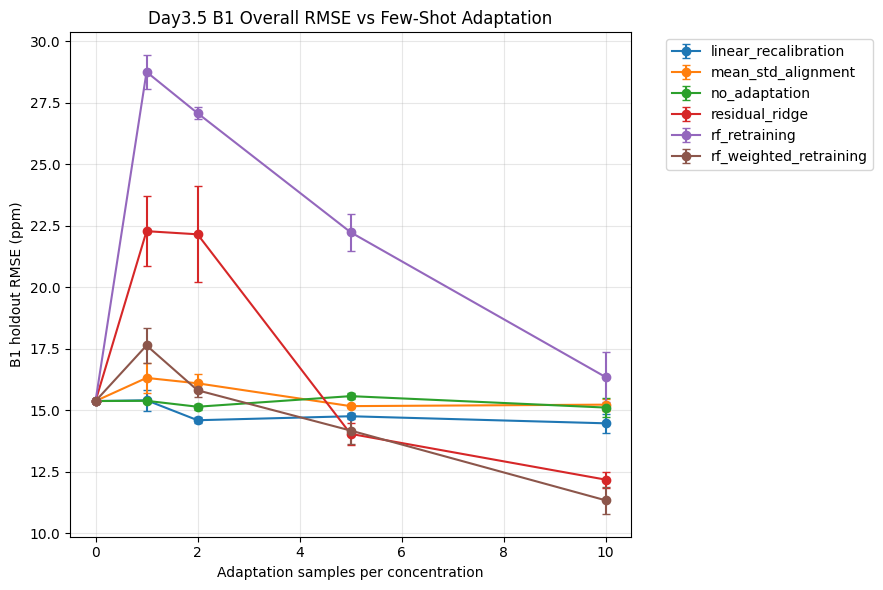

In [6]:
def summarize_mean_sem(results_df, metric):
    return (results_df
            .groupby(["shots_per_conc", "method"])[metric]
            .agg(["mean", "std", "count"])
            .reset_index()
            .assign(sem=lambda x: x["std"] / np.sqrt(x["count"].clip(lower=1))))

summary_rmse = summarize_mean_sem(b1_results, "rmse")
summary_rmse.to_csv(RESULTS_DIR / "b1_rmse_vs_shots_summary.csv", index=False)

plt.figure(figsize=(9, 6))
for method, g in summary_rmse.groupby("method"):
    plt.errorbar(g["shots_per_conc"], g["mean"], yerr=g["sem"], marker="o", capsize=3, label=method)
plt.xlabel("Adaptation samples per concentration")
plt.ylabel("B1 holdout RMSE (ppm)")
plt.title("Day3.5 B1 Overall RMSE vs Few-Shot Adaptation")
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "b1_rmse_vs_shots.png", dpi=200)
plt.show()

### Interpretation
Inspect whether RMSE decreases monotonically with shots and whether the best adapted method substantially improves over 0-shot transfer.

## Section 2 — High-Concentration Focus

### Goal
Evaluate whether adaptation specifically fixes the B1 high-concentration region where Day2+ found systematic compression.

### Method
Compute RMSE only for 80, 90, and 100 ppm holdout samples.

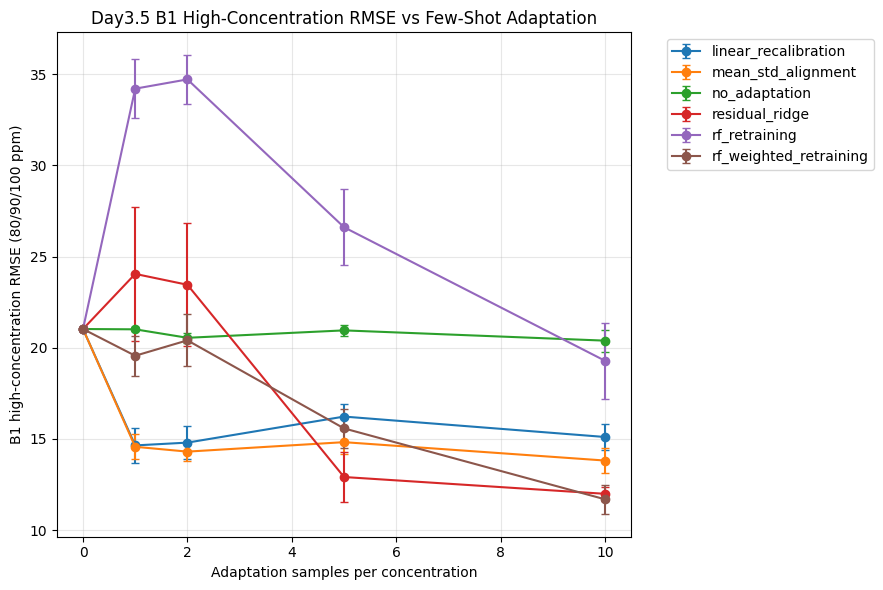

In [7]:
summary_high = summarize_mean_sem(b1_results, "highconc_rmse")
summary_high.to_csv(RESULTS_DIR / "b1_highconc_rmse_vs_shots_summary.csv", index=False)

plt.figure(figsize=(9, 6))
for method, g in summary_high.groupby("method"):
    plt.errorbar(g["shots_per_conc"], g["mean"], yerr=g["sem"], marker="o", capsize=3, label=method)
plt.xlabel("Adaptation samples per concentration")
plt.ylabel("B1 high-concentration RMSE (80/90/100 ppm)")
plt.title("Day3.5 B1 High-Concentration RMSE vs Few-Shot Adaptation")
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "b1_highconc_rmse_vs_shots.png", dpi=200)
plt.show()

### Interpretation
If high-concentration RMSE remains large after adaptation, B1 compression is not fully rescued. If it collapses toward low error with 1–2 shots, B1 behaves more like a correctable calibration-shift problem.

## Section 3 — Signed Error Before/After Adaptation

### Goal
Test whether the high-concentration negative bias disappears after the best adaptation.

### Method
Select the best B1 method/shot combination by mean RMSE. Compare mean signed error vs concentration for:
- no adaptation
- best adaptation

Best B1 adaptation: rf_weighted_retraining shots_per_conc= 10 mean RMSE= 11.344421204202195


,concentration_numeric,mean,std,count,condition
0,10.0,9.546875,10.683406,16,before_no_adaptation
1,20.0,9.343750,12.596999,16,before_no_adaptation
2,30.0,9.257812,10.664629,16,before_no_adaptation
3,40.0,4.953125,7.134551,16,before_no_adaptation
4,50.0,4.773438,11.348111,16,before_no_adaptation
5,60.0,-1.210938,10.191778,16,before_no_adaptation
6,70.0,-4.640625,9.065028,16,before_no_adaptation
7,80.0,-12.203125,9.394577,16,before_no_adaptation
8,90.0,-19.187500,8.003645,16,before_no_adaptation
9,100.0,-24.546875,8.230643,16,before_no_adaptation


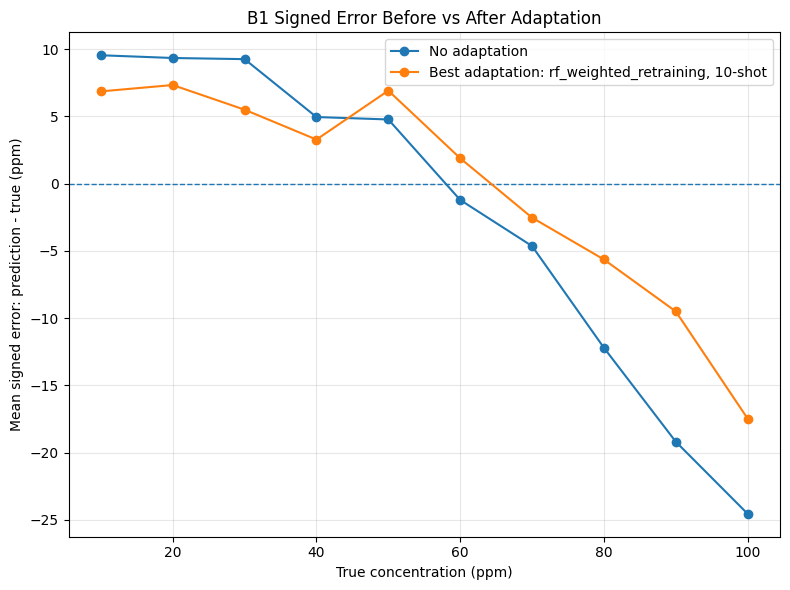

In [8]:
# Best adapted setting excludes no_adaptation and requires shots > 0.
adapted_only = b1_results[(b1_results["method"] != "no_adaptation") & (b1_results["shots_per_conc"] > 0)].copy()
best_row = (adapted_only.groupby(["method", "shots_per_conc"])["rmse"].mean().reset_index()
            .sort_values("rmse").iloc[0])
BEST_METHOD = best_row["method"]
BEST_SHOTS = int(best_row["shots_per_conc"])
print("Best B1 adaptation:", BEST_METHOD, "shots_per_conc=", BEST_SHOTS, "mean RMSE=", best_row["rmse"])

# Use repeat 0 for before/after diagnostic curves to keep exact sample identities transparent.
before = b1_preds[(b1_preds["method"] == "no_adaptation") & (b1_preds["shots_per_conc"] == 0) & (b1_preds["repeat"] == 0)].copy()
after = b1_preds[(b1_preds["method"] == BEST_METHOD) & (b1_preds["shots_per_conc"] == BEST_SHOTS) & (b1_preds["repeat"] == 0)].copy()

signed_before = before.groupby("concentration_numeric")["signed_error"].agg(["mean", "std", "count"]).reset_index()
signed_after = after.groupby("concentration_numeric")["signed_error"].agg(["mean", "std", "count"]).reset_index()
signed_before["condition"] = "before_no_adaptation"
signed_after["condition"] = f"after_{BEST_METHOD}_{BEST_SHOTS}shot"
signed_summary = pd.concat([signed_before, signed_after], ignore_index=True)
signed_summary.to_csv(RESULTS_DIR / "b1_signed_error_before_after.csv", index=False)

display(signed_summary)

plt.figure(figsize=(8, 6))
plt.axhline(0, linestyle="--", linewidth=1)
plt.plot(signed_before["concentration_numeric"], signed_before["mean"], marker="o", label="No adaptation")
plt.plot(signed_after["concentration_numeric"], signed_after["mean"], marker="o", label=f"Best adaptation: {BEST_METHOD}, {BEST_SHOTS}-shot")
plt.xlabel("True concentration (ppm)")
plt.ylabel("Mean signed error: prediction - true (ppm)")
plt.title("B1 Signed Error Before vs After Adaptation")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "b1_signed_error_before_after.png", dpi=200)
plt.show()

### Interpretation
The key visual test is whether the signed-error curve at 80–100 ppm moves back toward zero or remains strongly negative.

## Section 4 — Prediction vs True

### Goal
Check whether B1 response compression disappears after the best adaptation.

### Method
Plot prediction vs true for no adaptation and best adaptation. The diagonal is ideal calibration.

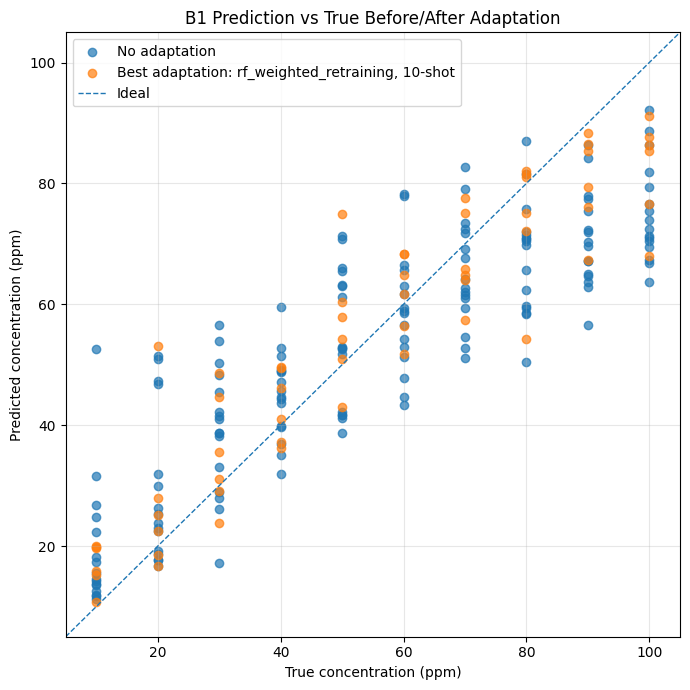

No adaptation slope=0.607, intercept=19.230
Best adaptation slope=0.749, intercept=13.496


In [9]:
plt.figure(figsize=(7, 7))
plt.scatter(before["y_true"], before["y_pred"], alpha=0.7, label="No adaptation")
plt.scatter(after["y_true"], after["y_pred"], alpha=0.7, label=f"Best adaptation: {BEST_METHOD}, {BEST_SHOTS}-shot")
lims = [min(before["y_true"].min(), before["y_pred"].min(), after["y_true"].min(), after["y_pred"].min()) - 5,
        max(before["y_true"].max(), before["y_pred"].max(), after["y_true"].max(), after["y_pred"].max()) + 5]
plt.plot(lims, lims, linestyle="--", linewidth=1, label="Ideal")
plt.xlim(lims)
plt.ylim(lims)
plt.xlabel("True concentration (ppm)")
plt.ylabel("Predicted concentration (ppm)")
plt.title("B1 Prediction vs True Before/After Adaptation")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "b1_prediction_vs_true_before_after.png", dpi=200)
plt.show()

# Quantify compression slope: predicted vs true at diagnostic settings.
def compression_slope(d):
    lr = LinearRegression().fit(d[["y_true"]].values, d["y_pred"].values)
    return float(lr.coef_[0]), float(lr.intercept_)

slope_before, intercept_before = compression_slope(before)
slope_after, intercept_after = compression_slope(after)
print(f"No adaptation slope={slope_before:.3f}, intercept={intercept_before:.3f}")
print(f"Best adaptation slope={slope_after:.3f}, intercept={intercept_after:.3f}")

### Interpretation
A slope far below 1 or persistent underprediction at 100 ppm indicates remaining compression. A slope closer to 1 after adaptation indicates correction.

## Section 5 — B1 vs B5 Adaptation Comparison

### Goal
Compare whether B1 adaptation is harder than B5 adaptation.

### Method
Use Day3 B5 results if available. If not found, recompute B5 using the same pipeline with source boards B1+B2+B3+B4 and target B5.

No reusable Day3 B5 result file found. Recomputing B5 with same Day3.5 pipeline...


,shots_per_conc,method,rmse,target
0,0,linear_recalibration,15.380744,B1
1,1,no_adaptation,15.389965,B1
2,2,linear_recalibration,14.601196,B1
3,5,residual_ridge,14.046726,B1
4,10,rf_weighted_retraining,11.344421,B1
5,0,linear_recalibration,24.395424,B5
6,1,rf_weighted_retraining,22.058343,B5
7,2,rf_weighted_retraining,20.307033,B5
8,5,rf_weighted_retraining,16.264477,B5


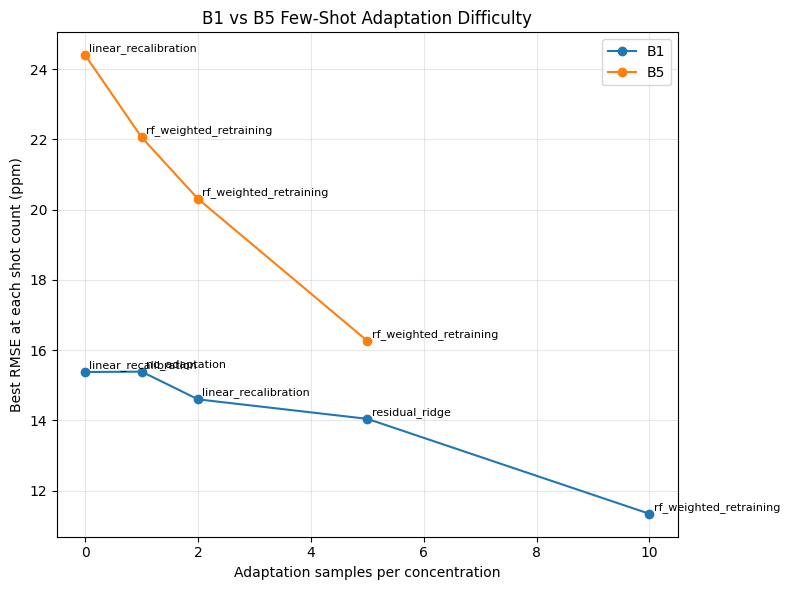

In [10]:
def load_existing_b5_results():
    candidates = [
        RESULTS_DIR / "b5_adaptation_results.csv",
        RESULTS_DIR / "day3_b5_adaptation_results.csv",
        RESULTS_DIR / "fewshot_adaptation_results.csv",
        RESULTS_DIR / "day3_fewshot_results.csv",
    ]
    for p in candidates:
        if p.exists():
            x = pd.read_csv(p)
            cols = set(x.columns)
            if {"shots_per_conc", "method", "rmse"}.issubset(cols):
                print("Loaded existing B5 results:", p)
                if "target" not in x.columns:
                    x["target"] = "B5"
                return x
    return None

b5_results = load_existing_b5_results()
if b5_results is None:
    print("No reusable Day3 B5 result file found. Recomputing B5 with same Day3.5 pipeline...")
    b5_results, b5_preds = evaluate_target("B5", ["B1", "B2", "B3", "B4"], n_repeats=N_REPEATS)
    b5_results.to_csv(RESULTS_DIR / "b5_adaptation_results_recomputed_day35.csv", index=False)
else:
    # Normalize possible shot column names.
    if "shots" in b5_results.columns and "shots_per_conc" not in b5_results.columns:
        b5_results = b5_results.rename(columns={"shots": "shots_per_conc"})

# Choose best method per target and shot by mean RMSE.
def best_curve(results_df, target_label):
    r = results_df.copy()
    if "target" in r.columns:
        r = r[r["target"].astype(str).str.upper() == target_label.upper()].copy()
    if r.empty:
        r = results_df.copy()
    # For each shot, show the best available adapted/no-adapt method mean.
    curve = (r.groupby(["shots_per_conc", "method"])["rmse"].mean().reset_index()
             .sort_values(["shots_per_conc", "rmse"])
             .groupby("shots_per_conc").head(1)
             .sort_values("shots_per_conc"))
    curve["target"] = target_label
    return curve

b1_curve = best_curve(b1_results, "B1")
b5_curve = best_curve(b5_results, "B5")
comparison_curve = pd.concat([b1_curve, b5_curve], ignore_index=True)
comparison_curve.to_csv(RESULTS_DIR / "b1_vs_b5_best_adaptation_curve.csv", index=False)

display(comparison_curve)

plt.figure(figsize=(8, 6))
for target, g in comparison_curve.groupby("target"):
    plt.plot(g["shots_per_conc"], g["rmse"], marker="o", label=target)
    for _, row in g.iterrows():
        plt.annotate(row["method"], (row["shots_per_conc"], row["rmse"]), fontsize=8, xytext=(3, 3), textcoords="offset points")
plt.xlabel("Adaptation samples per concentration")
plt.ylabel("Best RMSE at each shot count (ppm)")
plt.title("B1 vs B5 Few-Shot Adaptation Difficulty")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "b1_vs_b5_adaptation.png", dpi=200)
plt.show()

### Interpretation
If B5 improves sharply with few shots while B1 improves weakly or retains high-concentration bias, the two failure modes are empirically different.

## Section 6 — Failure Mode Validation

### Goal
Create the required summary table and decide whether B1 is fixed or remains target-intrinsic.

### Method
Compare 0-shot RMSE, best RMSE, and relative improvement for B1 and B5.

In [11]:
def failure_summary_for(results_df, target, failure_mode):
    r = results_df.copy()
    if "target" in r.columns:
        rr = r[r["target"].astype(str).str.upper() == target.upper()].copy()
        if not rr.empty:
            r = rr
    mean_by = r.groupby(["shots_per_conc", "method"])["rmse"].mean().reset_index()
    zero = mean_by[mean_by["shots_per_conc"] == 0]["rmse"].min()
    best_row = mean_by.sort_values("rmse").iloc[0]
    best = best_row["rmse"]
    rel = (zero - best) / zero if zero else np.nan
    return {
        "Target": target,
        "Failure Mode": failure_mode,
        "0-shot RMSE": zero,
        "Best RMSE": best,
        "Best Method": best_row["method"],
        "Best Shots": int(best_row["shots_per_conc"]),
        "Relative Improvement": rel,
    }

failure_summary = pd.DataFrame([
    failure_summary_for(b1_results, "B1", "Target-intrinsic ?"),
    failure_summary_for(b5_results, "B5", "Coverage-limited"),
])
failure_summary.to_csv(RESULTS_DIR / "failure_mode_summary.csv", index=False)
display(failure_summary)

,Target,Failure Mode,0-shot RMSE,Best RMSE,Best Method,Best Shots,Relative Improvement
0,B1,Target-intrinsic ?,15.380744,11.344421,rf_weighted_retraining,10,0.262427
1,B5,Coverage-limited,24.395424,16.264477,rf_weighted_retraining,5,0.333298


In [12]:
# Automatic interpretation support metrics.
high_before = before[np.isin(before["y_true"], HIGH_CONCS)]["signed_error"].mean()
high_after = after[np.isin(after["y_true"], HIGH_CONCS)]["signed_error"].mean()
zero_b1 = failure_summary.loc[failure_summary["Target"] == "B1", "0-shot RMSE"].iloc[0]
best_b1 = failure_summary.loc[failure_summary["Target"] == "B1", "Best RMSE"].iloc[0]
rel_b1 = failure_summary.loc[failure_summary["Target"] == "B1", "Relative Improvement"].iloc[0]
zero_b5 = failure_summary.loc[failure_summary["Target"] == "B5", "0-shot RMSE"].iloc[0]
best_b5 = failure_summary.loc[failure_summary["Target"] == "B5", "Best RMSE"].iloc[0]
rel_b5 = failure_summary.loc[failure_summary["Target"] == "B5", "Relative Improvement"].iloc[0]

print("B1 high-conc signed error before:", high_before)
print("B1 high-conc signed error after:", high_after)
print("B1 relative improvement:", rel_b1)
print("B5 relative improvement:", rel_b5)

B1 high-conc signed error before: -18.645833333333332
B1 high-conc signed error after: -10.870370370370372
B1 relative improvement: 0.26242701755663234
B5 relative improvement: 0.3332980410608037


## Day3.5 Observations

### 1. Can few-shot adaptation rescue B1?
Use `failure_mode_summary.csv`, `b1_rmse_vs_shots.png`, and `b1_highconc_rmse_vs_shots.png`.

- If B1 RMSE drops strongly and high-concentration signed error approaches zero, then few-shot adaptation rescues B1.
- If B1 RMSE improves only partially and 80–100 ppm remains negatively biased, then adaptation does not fully rescue B1.

### 2. Is B1 fundamentally different from B5?
Use `b1_vs_b5_adaptation.png`.

- If B5 shows a larger relative improvement and faster few-shot recovery than B1, B1 and B5 represent different failure modes.
- If B1 improves similarly to B5, the Day2+ target-intrinsic interpretation should be weakened.

### 3. Does B1 remain target-intrinsic after adaptation?
Use `b1_signed_error_before_after.png` and `b1_prediction_vs_true_before_after.png`.

- Persistent high-concentration underprediction after best adaptation supports the target-intrinsic hypothesis.
- Disappearance of compression suggests B1 is not fundamentally defective; it is correctable with target labels.

### 4. What is the next scientific question?
The next question should be:

> What physical or feature-space mechanism creates B1 high-concentration compression, and can a physics-aware monotonic/saturation model correct it more reliably than generic few-shot adaptation?

This naturally leads to a Day4/Day4.5 experiment comparing generic ML adaptation with physically constrained response models.

## Final Debug Review

### Goal
Verify that Day3.5 can run end-to-end and that all required outputs are created.

### Method
Check paths, filenames, DataFrame columns, `feature_cols`, adaptation functions, `random_state`, figure saving, and CSV saving.

In [13]:
required_figures = [
    "b1_rmse_vs_shots.png",
    "b1_highconc_rmse_vs_shots.png",
    "b1_signed_error_before_after.png",
    "b1_prediction_vs_true_before_after.png",
    "b1_vs_b5_adaptation.png",
]
required_results = [
    "failure_mode_summary.csv",
    "b1_adaptation_results.csv",
    "b1_adaptation_predictions.csv",
]

checks = []
checks.append(("PROJECT_ROOT exists", PROJECT_ROOT.exists()))
checks.append(("DATA_RAW exists", DATA_RAW.exists()))
checks.append(("FIGURES_DIR exists", FIGURES_DIR.exists()))
checks.append(("RESULTS_DIR exists", RESULTS_DIR.exists()))
checks.append(("df has rows", len(df) > 0))
checks.append(("required columns", all(c in df.columns for c in ["board", "concentration_numeric"])))
checks.append(("feature_cols non-empty", len(feature_cols) > 0))
checks.append(("B1 exists", "B1" in set(df["board"])))
checks.append(("B1 source boards exist", all(b in set(df["board"]) for b in b1_source_boards)))
checks.append(("RANDOM_STATE fixed", RANDOM_STATE == 42))
checks.append(("memory-safe RF_N_JOBS", RF_N_JOBS == 1))
checks.append(("memory-safe N_REPEATS", N_REPEATS <= 5))
checks.append(("adaptation methods complete", set(METHODS) == set(["no_adaptation", "mean_std_alignment", "linear_recalibration", "residual_ridge", "rf_retraining", "rf_weighted_retraining"])))
for f in required_figures:
    checks.append((f"figure saved: {f}", (FIGURES_DIR / f).exists()))
for f in required_results:
    checks.append((f"result saved: {f}", (RESULTS_DIR / f).exists()))

review = pd.DataFrame(checks, columns=["check", "passed"])
display(review)

if not review["passed"].all():
    failed = review.loc[~review["passed"], "check"].tolist()
    raise AssertionError("Debug Review failed: " + "; ".join(failed))
else:
    print("Debug Review passed. Day3.5 notebook completed successfully.")

,check,passed
0,PROJECT_ROOT exists,True
1,DATA_RAW exists,True
2,FIGURES_DIR exists,True
3,RESULTS_DIR exists,True
4,df has rows,True
5,required columns,True
6,feature_cols non-empty,True
7,B1 exists,True
8,B1 source boards exist,True
9,RANDOM_STATE fixed,True


Debug Review passed. Day3.5 notebook completed successfully.
